# 臺灣月最高溫網格資料：合併、EDA 與 GEV NN 分析

這份 notebook 把老師指定的 `觀測_月資料_臺灣_最高溫` 資料重新整理成跟原本測站資料相同的分析型態。原本的 25 測站資料是 `Date × station`，這批資料則是 `LON/LAT × 月份` 的網格資料，所以這裡把每個 `(lon, lat)` 網格點視為一個 station，命名為 `G經度_緯度`。

主要流程：

1. 只讀取檔名為 `觀測_月資料_臺灣_最高溫_YYYY.csv` 的最高溫資料，先不混入資料夾內的參考測站距離與標準差檔。
2. 將每年 12 個月份欄位合併成 long table，再 pivot 成 `Date × grid station`。
3. 1980 年後資料做 coverage 篩選，避免大量缺值網格干擾。
4. 跟原本測站分析一樣，將月最高溫轉成年最大值。
5. 使用原專案已訓練好的 GEV neural network 模型，估計每個網格點的 `mu`、`sigma`、`xi`。
6. 輸出 EDA 圖、NN 參數圖，以及沿用原專案想法的 GP/Kriging 空間平滑結果。

## 1. 專案與套件設定

這一段只做路徑與套件設定。新專案不複製原始資料，直接從原始專案的最高溫資料夾讀取；所有合併後資料與分析結果會輸出到本專案底下。

In [2]:

from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel

warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# 路徑設定
# =========================
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = Path(r"C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\original_data\觀測_月資料_臺灣_最高溫")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_PATH = PROJECT_ROOT / "models" / "best_baseline_model.pth"
SHAPEFILE_PATH = Path(r"C:\\Users\\User.DESKTOP-4RV84M1\\Desktop\\論文\\fast parameter estimate\\fast_parameter_using_NN\\data\\shapefile\\ne_50m_admin_0_countries\\ne_50m_admin_0_countries.shp")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR exists:", RAW_DIR.exists())
print("MODEL_PATH exists:", MODEL_PATH.exists())

PROJECT_ROOT: c:\Users\User.DESKTOP-4RV84M1\Desktop\high_temp_gev_nn_project
RAW_DIR exists: True
MODEL_PATH exists: True


## 2. 資料合併

原始資料每一年一個 CSV，每列是一個經緯度網格點，每欄是該年的 12 個月份。這裡將所有年份接起來，並轉成兩份主要資料：

- `monthly_long_grid_temperature.csv`：long format，方便檢查與追蹤來源。
- `pivot_grid_monthly_max_temperature_all.csv`：跟原本測站資料一樣的 `Date × station` 格式。

In [ ]:

# =========================
# 讀取與合併每年最高溫月資料
# =========================
def read_one_year_temperature_csv(path: Path) -> pd.DataFrame:
    """讀單一年份最高溫檔，轉成 long format: date, station, lon, lat, max_temp。"""
    year_match = re.search(r"_(\d{4})\.csv$", path.name)
    year = int(year_match.group(1)) if year_match else None

    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]
    df.columns = [str(c).strip() for c in df.columns]

    df["LON"] = pd.to_numeric(df["LON"], errors="coerce").round(2)
    df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce").round(2)

    month_cols = [c for c in df.columns if re.fullmatch(r"\d{6}", str(c))]
    if year is not None:
        month_cols = [c for c in month_cols if str(c).startswith(str(year))]

    long_df = df.melt(
        id_vars=["LON", "LAT"],
        value_vars=month_cols,
        var_name="yyyymm",
        value_name="max_temp",
    )
    long_df["max_temp"] = pd.to_numeric(long_df["max_temp"], errors="coerce")
    long_df.loc[long_df["max_temp"] <= -90, "max_temp"] = np.nan
    long_df["date"] = pd.to_datetime(long_df["yyyymm"] + "01", format="%Y%m%d")
    long_df["station"] = "G" + long_df["LON"].map(lambda x: f"{x:.2f}") + "_" + long_df["LAT"].map(lambda x: f"{x:.2f}")
    return long_df[["date", "station", "LON", "LAT", "max_temp"]]

files = sorted(RAW_DIR.glob("觀測_月資料_臺灣_最高溫_*.csv"))
print("最高溫年度檔數:", len(files))
print("年份範圍:", files[0].stem[-4:], "到", files[-1].stem[-4:])

monthly_long = pd.concat([read_one_year_temperature_csv(p) for p in files], ignore_index=True)
monthly_long = monthly_long.rename(columns={"LON": "lon", "LAT": "lat"})

station_location = monthly_long[["station", "lat", "lon"]].drop_duplicates("station").sort_values("station")

pivot_all = monthly_long.pivot_table(index="date", columns="station", values="max_temp", aggfunc="first").sort_index()

print("long shape:", monthly_long.shape)
print("pivot shape:", pivot_all.shape)
print("網格點數:", station_location.shape[0])
pivot_all.head()

最高溫年度檔數: 65
年份範圍: 1960 到 2024
long shape: (1147368, 5)
pivot shape: (780, 1412)
網格點數: 1471


TypeError: 'DataFrame' object is not callable

## 3. EDA 與缺值篩選

這批網格資料比原本測站資料雜，很多海面或邊界點會出現 `-99.9`，這裡統一視為缺值。為了讓後續 GEV 估計穩定，1980 年後有效月份比例至少要達到 80% 才保留。這個門檻寫在 `MIN_MONTH_COVERAGE`，之後可以視老師要求調整。

                 item        value
0      raw_year_files    65.000000
1     all_grid_points  1412.000000
2   months_after_1980   540.000000
3    kept_grid_points  1412.000000
4  coverage_threshold     0.800000
5     temperature_min     2.372200
6    temperature_mean    24.394431
7     temperature_max    35.878500


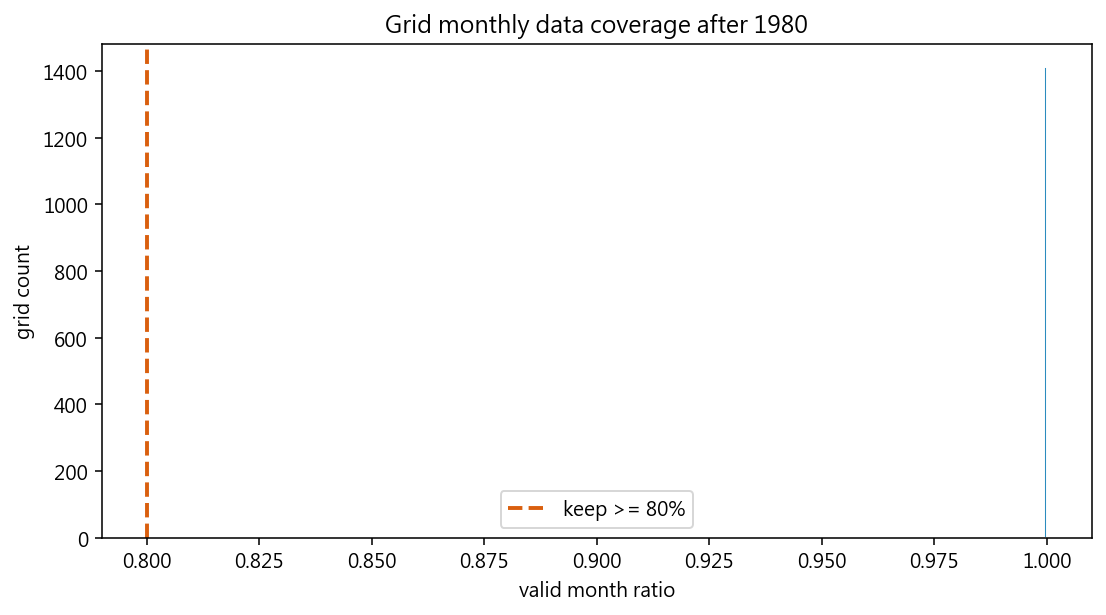

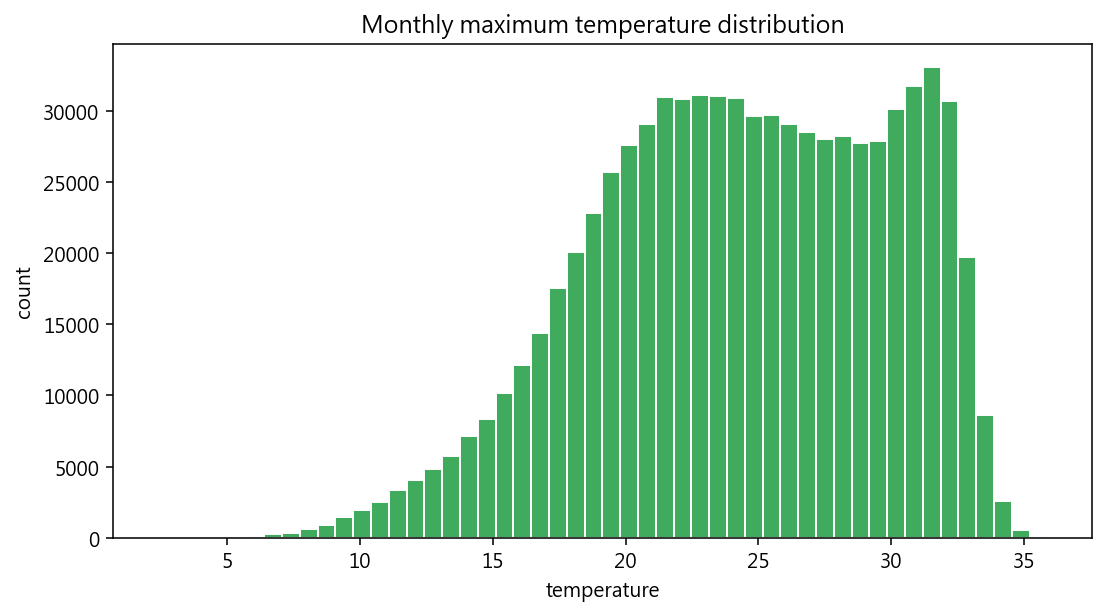

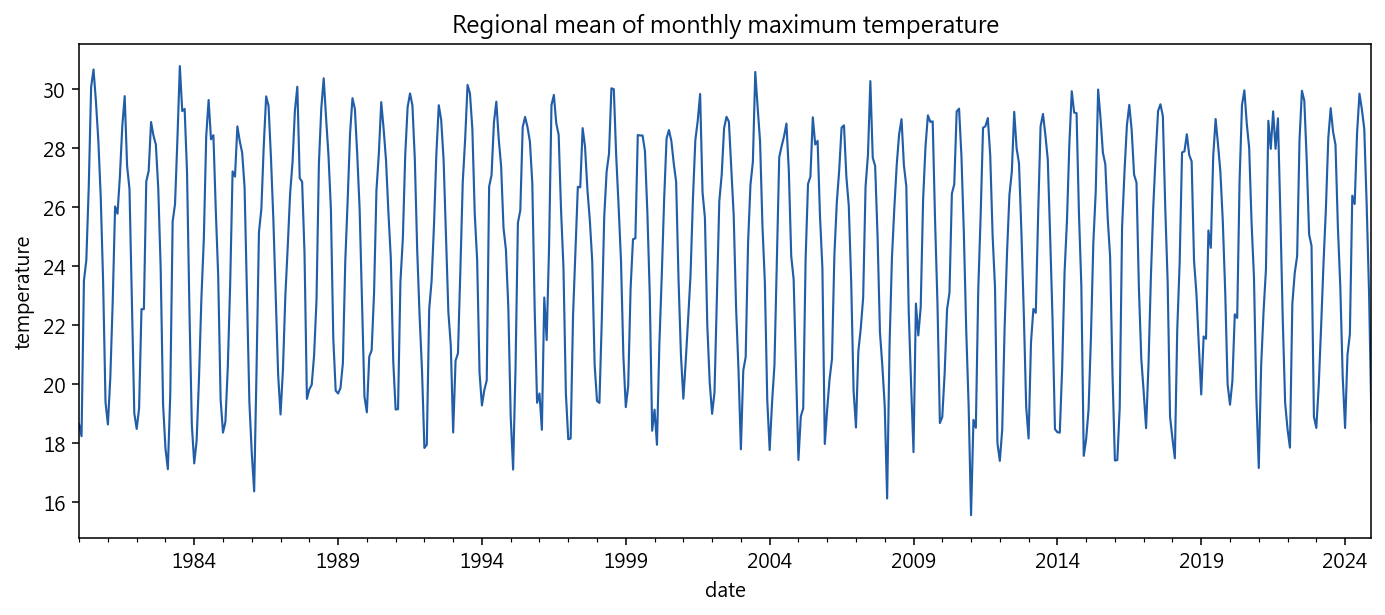

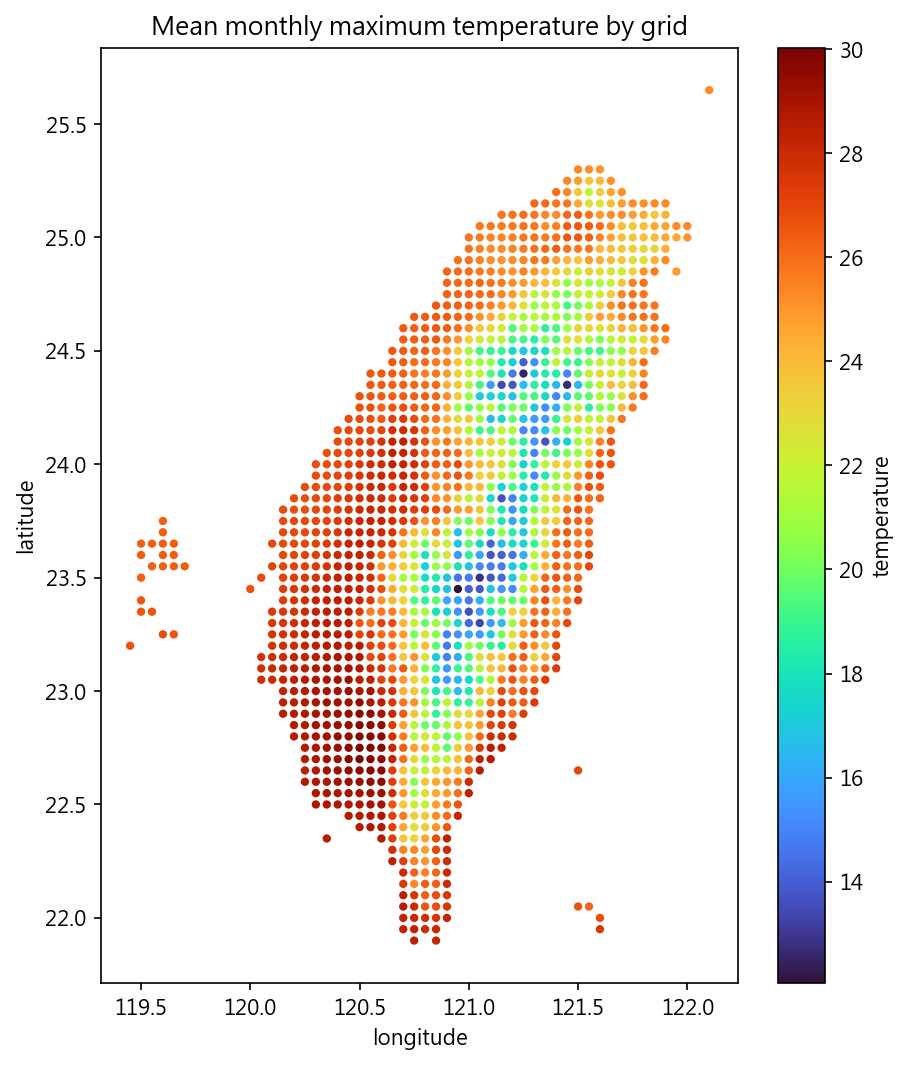

保留網格點: 1412
EDA figures saved to c:\Users\User.DESKTOP-4RV84M1\Desktop\high_temp_gev_nn_project\results\figures


In [4]:

# =========================
# EDA：缺值、coverage、時間範圍、溫度分布
# =========================
analysis_start = pd.Timestamp("1980-01-01")
pivot = pivot_all[pivot_all.index >= analysis_start].copy()

coverage = pivot.notna().mean().rename("valid_month_ratio").reset_index()
coverage = coverage.merge(station_location, on="station", how="left")
coverage["valid_months"] = pivot.notna().sum().values
coverage = coverage.sort_values("valid_month_ratio", ascending=False)

MIN_MONTH_COVERAGE = 0.80
keep_stations = coverage.loc[coverage["valid_month_ratio"] >= MIN_MONTH_COVERAGE, "station"].tolist()
pivot_clean = pivot[keep_stations].copy()

summary = pd.DataFrame({
    "item": [
        "raw_year_files", "all_grid_points", "months_after_1980", "kept_grid_points",
        "coverage_threshold", "temperature_min", "temperature_mean", "temperature_max"
    ],
    "value": [
        len(files), pivot_all.shape[1], pivot.shape[0], len(keep_stations),
        MIN_MONTH_COVERAGE, float(np.nanmin(pivot_clean.values)), float(np.nanmean(pivot_clean.values)), float(np.nanmax(pivot_clean.values))
    ]
})
print(summary)

# 圖 1：coverage 分布
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=140)
ax.hist(coverage["valid_month_ratio"], bins=30, color="#2b8cbe", edgecolor="white")
ax.axvline(MIN_MONTH_COVERAGE, color="#d95f0e", linestyle="--", linewidth=2, label=f"keep >= {MIN_MONTH_COVERAGE:.0%}")
ax.set_title("Grid monthly data coverage after 1980")
ax.set_xlabel("valid month ratio")
ax.set_ylabel("grid count")
ax.legend()
fig.tight_layout()
plt.show()

# 圖 2：月最高溫整體分布
values = pivot_clean.to_numpy().ravel()
values = values[~np.isnan(values)]
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=140)
ax.hist(values, bins=50, color="#41ab5d", edgecolor="white")
ax.set_title("Monthly maximum temperature distribution")
ax.set_xlabel("temperature")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

# 圖 3：每月全區平均最高溫時間序列
monthly_mean = pivot_clean.mean(axis=1)
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
monthly_mean.plot(ax=ax, color="#225ea8", linewidth=1.1)
ax.set_title("Regional mean of monthly maximum temperature")
ax.set_xlabel("date")
ax.set_ylabel("temperature")
fig.tight_layout()
plt.show()

# 圖 4：有效網格點平均溫度空間分布
mean_by_station = pivot_clean.mean(axis=0).rename("mean_temp").reset_index()
mean_map = mean_by_station.merge(station_location, on="station", how="left")
fig, ax = plt.subplots(figsize=(6.2, 7.2), dpi=150)
sc = ax.scatter(mean_map["lon"], mean_map["lat"], c=mean_map["mean_temp"], s=9, cmap="turbo")
ax.set_title("Mean monthly maximum temperature by grid")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(sc, ax=ax, label="temperature")
fig.tight_layout()
plt.show()

print("保留網格點:", len(keep_stations))
print("EDA figures saved to", FIG_DIR)

## 4. 轉成年最大值

原本測站流程是先把月資料轉成年最大值，這裡照同樣做法。每個網格點至少需要 30 年有效年最大值，因為原 NN 模型訓練時的最小樣本數也是 30。

In [5]:

# =========================
# 轉成跟原本測站分析一樣的年最大值資料
# =========================
annual_max = pivot_clean.resample("YE").max()
annual_max.index = annual_max.index.year
annual_max.index.name = "year"

# 年最大值至少要有 30 年，對齊原 NN 訓練 sample size 下限
valid_annual_counts = annual_max.notna().sum()
annual_keep = valid_annual_counts[valid_annual_counts >= 30].index.tolist()
annual_max = annual_max[annual_keep]

annual_loc = station_location[station_location["station"].isin(annual_keep)].copy()

print("annual_max shape:", annual_max.shape)
annual_max.head()

annual_max shape: (45, 1412)


station,G122.00_25.05,G119.45_23.20,G119.50_23.35,G121.80_24.45,G121.80_24.50,G121.80_24.55,G121.80_24.60,G121.80_24.65,G121.80_24.70,G121.80_24.75,...,G119.65_23.65,G119.50_23.50,G119.50_23.60,G119.50_23.65,G119.55_23.35,G119.55_23.55,G119.55_23.65,G119.60_23.25,G119.60_23.55,G122.10_25.65
year,,,,,,,,,,,,,,,,,,,,,
1980,33.3814,32.6751,32.7607,33.7142,31.7684,31.1531,33.7237,34.2901,34.2917,33.9893,...,32.2219,32.3782,31.9809,32.0062,32.7796,32.3083,32.0969,32.8400,32.2798,33.2531
1981,32.8903,31.7795,31.8686,33.9615,31.1933,30.3796,33.7523,34.3766,34.3667,34.3229,...,31.4734,31.5749,31.2650,31.2837,31.8889,31.5380,31.3663,31.9424,31.5188,33.0507
1982,30.9936,31.0390,31.0539,31.6691,29.8866,29.0868,31.2059,31.6354,31.5957,31.4646,...,30.9054,30.9083,30.7687,30.7806,31.0735,30.7747,30.8435,31.2049,30.8668,32.1042
1983,33.1141,32.9358,32.8381,33.3491,32.1841,31.3892,32.9198,33.3734,33.3699,33.2599,...,32.6032,32.2862,32.4686,32.4775,32.8581,32.4514,32.5388,33.1526,32.5794,34.0496
1984,32.4484,31.6492,31.4899,32.5122,30.5873,29.9422,32.3988,32.8085,32.7940,32.6767,...,31.2969,30.9254,31.1498,31.1608,31.5106,31.1156,31.2258,31.8395,31.2714,33.5104


## 5. GEV Neural Network 估參數

這裡直接使用原專案的 `best_baseline_model.pth`。每個網格點的年最大值序列會先做 median/IQR robust standardization，再取 11 個分位數作為 NN input，與原本流程一致。

In [6]:

# =========================
# 使用原本訓練好的 GEV NN 估計每個網格點參數
# =========================
P_SET = np.array([0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 0.9999])

class GEVNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.net(x)

def make_nn_input(y):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    med = np.median(y)
    q1, q3 = np.quantile(y, [0.25, 0.75])
    iqr = q3 - q1
    if iqr <= 1e-12:
        raise ValueError("IQR too small")
    z = (y - med) / iqr
    q = np.quantile(z, P_SET)
    return q, med, iqr

def estimate_one_station(model, y, device):
    q, med, iqr = make_nn_input(y)
    x = torch.tensor(q, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).cpu().numpy().ravel()
    mu_star, delta_star, xi_hat = pred
    sigma_hat = float(np.exp(delta_star) * iqr)
    mu_hat = float(mu_star * iqr + med)
    return mu_hat, sigma_hat, float(xi_hat)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
model = GEVNet().to(device)
try:
    state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

results = []
for station in annual_max.columns:
    y = annual_max[station].dropna().to_numpy()
    if len(y) < 30:
        continue
    try:
        mu, sigma, xi = estimate_one_station(model, y, device)
        results.append({
            "station": station,
            "n_obs": int(len(y)),
            "mu_hat": mu,
            "sigma_hat": sigma,
            "log_sigma_hat": float(np.log(sigma)),
            "xi_hat": xi,
        })
    except Exception as exc:
        print("skip", station, exc)

station_gev = pd.DataFrame(results)
station_gev = station_gev.merge(annual_loc, on="station", how="left")
print("estimated stations:", station_gev.shape[0])
station_gev.head()

device: cuda
estimated stations: 1412


,station,n_obs,mu_hat,sigma_hat,log_sigma_hat,xi_hat,lat,lon
0,G122.00_25.05,45,32.167812,0.251798,-1.379129,0.247499,25.05,122.00
1,G119.45_23.20,45,31.698334,0.238125,-1.434958,0.227292,23.20,119.45
2,G119.50_23.35,45,31.679490,0.279867,-1.273440,0.180436,23.35,119.50
3,G121.80_24.45,45,31.973499,0.315164,-1.154663,0.157636,24.45,121.80
4,G121.80_24.50,45,30.100477,0.424242,-0.857451,0.172721,24.50,121.80


## 6. NN 結果檢查與圖形

輸出每個網格點的 GEV 參數，並畫出 `mu`、`sigma`、`xi` 的空間分布。另用每個網格點的年最大值平均和 `mu_hat` 做散佈圖，快速檢查 NN 估計尺度是否合理。

                count       mean       std        min        25%        50%  \
mu_hat         1412.0  29.246515  4.131927  16.399114  26.837373  31.162321   
sigma_hat      1412.0   0.371804  0.145508   0.090590   0.285479   0.349497   
log_sigma_hat  1412.0  -1.057337  0.366968  -2.401416  -1.253586  -1.051259   
xi_hat         1412.0   0.129251  0.116656  -0.360854   0.062110   0.142929   

                     75%        max  
mu_hat         32.410737  33.948245  
sigma_hat       0.423332   1.075406  
log_sigma_hat  -0.859598   0.072698  
xi_hat          0.218774   0.393741  


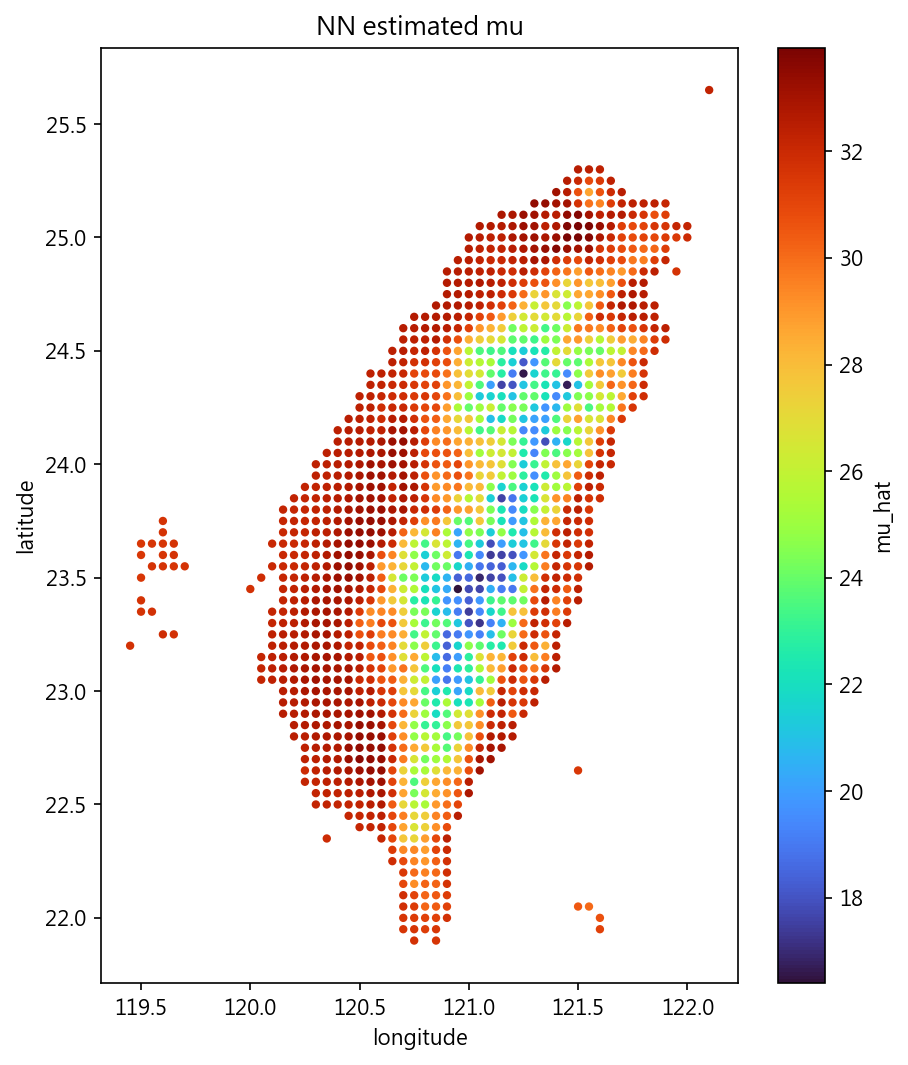

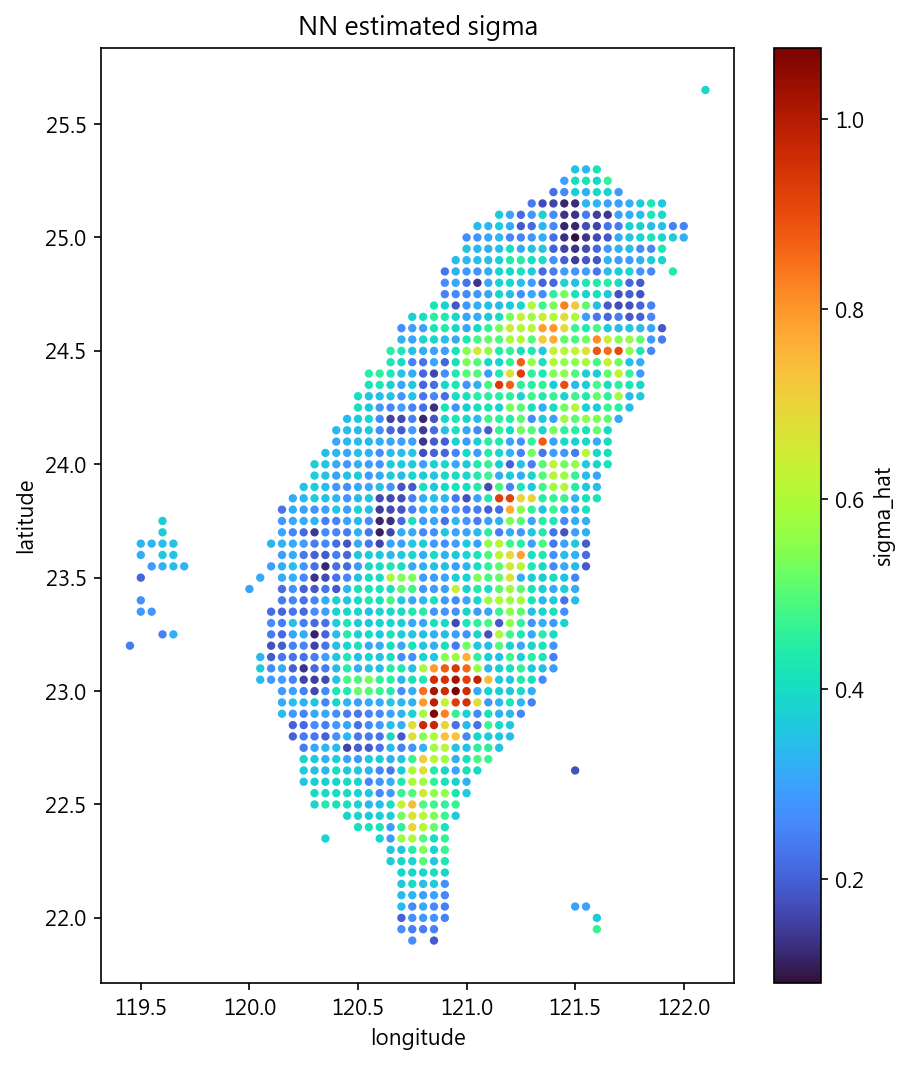

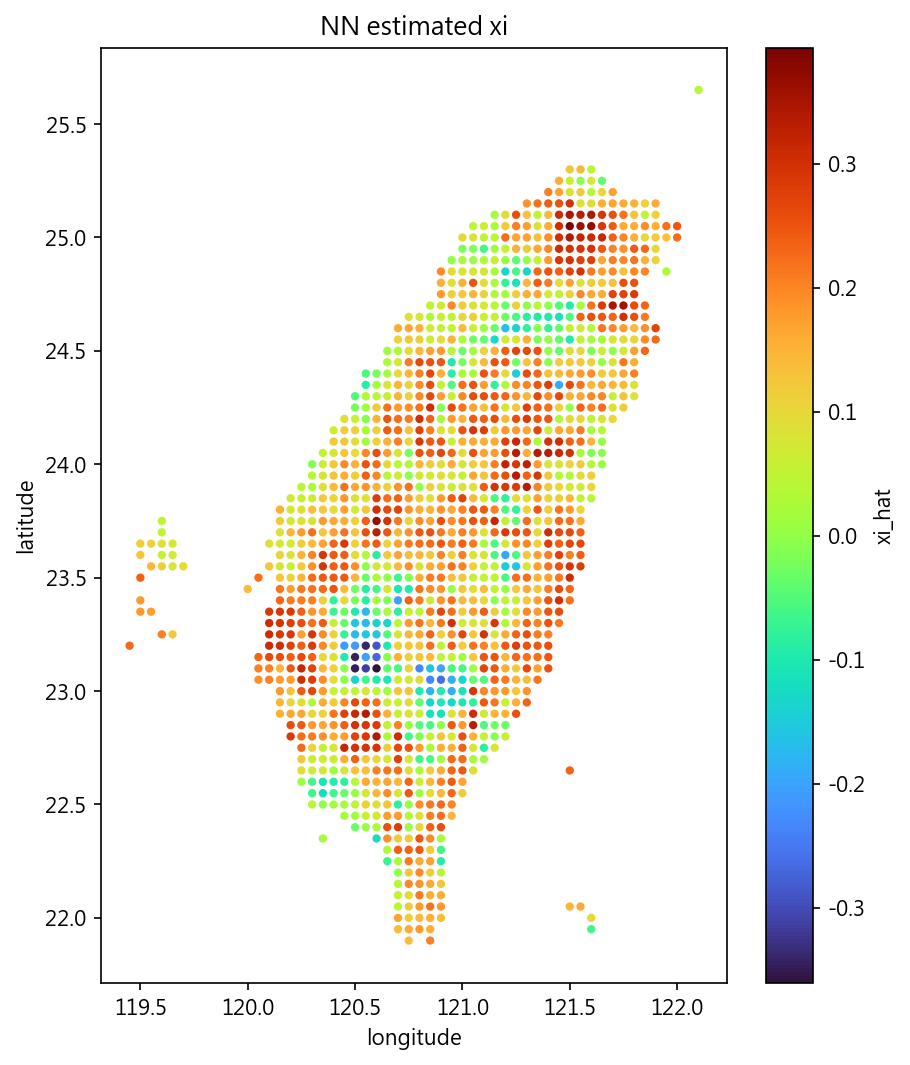

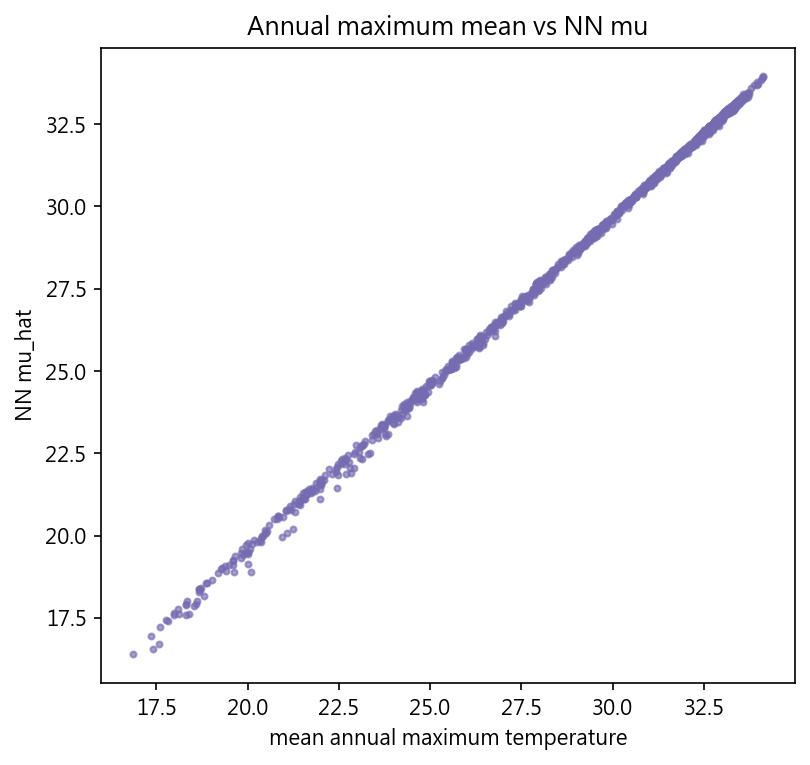

figures saved to c:\Users\User.DESKTOP-4RV84M1\Desktop\high_temp_gev_nn_project\results\figures


In [7]:

# =========================
# 結果圖：NN 參數空間分布與簡單比較指標
# =========================
param_summary = station_gev[["mu_hat", "sigma_hat", "log_sigma_hat", "xi_hat"]].describe().T
print(param_summary)

plot_specs = [
    ("mu_hat", "NN estimated mu", "map_nn_mu.png"),
    ("sigma_hat", "NN estimated sigma", "map_nn_sigma.png"),
    ("xi_hat", "NN estimated xi", "map_nn_xi.png"),
]

for col, title, filename in plot_specs:
    fig, ax = plt.subplots(figsize=(6.2, 7.2), dpi=150)
    sc = ax.scatter(station_gev["lon"], station_gev["lat"], c=station_gev[col], s=9, cmap="turbo")
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    fig.colorbar(sc, ax=ax, label=col)
    fig.tight_layout()
    plt.show()

# 年最大值全區平均與 NN mu 的關係，檢查估計是否跟資料尺度一致
annual_station_mean = annual_max.mean(axis=0).rename("annual_max_mean").reset_index()
check_df = station_gev.merge(annual_station_mean, on="station", how="left")

fig, ax = plt.subplots(figsize=(5.5, 5.2), dpi=150)
ax.scatter(check_df["annual_max_mean"], check_df["mu_hat"], s=8, alpha=0.65, color="#756bb1")
ax.set_title("Annual maximum mean vs NN mu")
ax.set_xlabel("mean annual maximum temperature")
ax.set_ylabel("NN mu_hat")
fig.tight_layout()
plt.show()

corr = check_df[["annual_max_mean", "mu_hat", "sigma_hat", "xi_hat"]].corr(numeric_only=True)
print("figures saved to", FIG_DIR)

## 7. 空間平滑/Kriging

原本 25 測站需要 kriging 才能推到空間場。這批資料本身已經是密集網格，所以直接畫 NN 估計其實已經有完整空間圖。為了和原本分析保持一致，這裡仍然做 Gaussian Process/Kriging 平滑；但網格點數很多，訓練時最多抽 800 個點，避免計算時間過長。

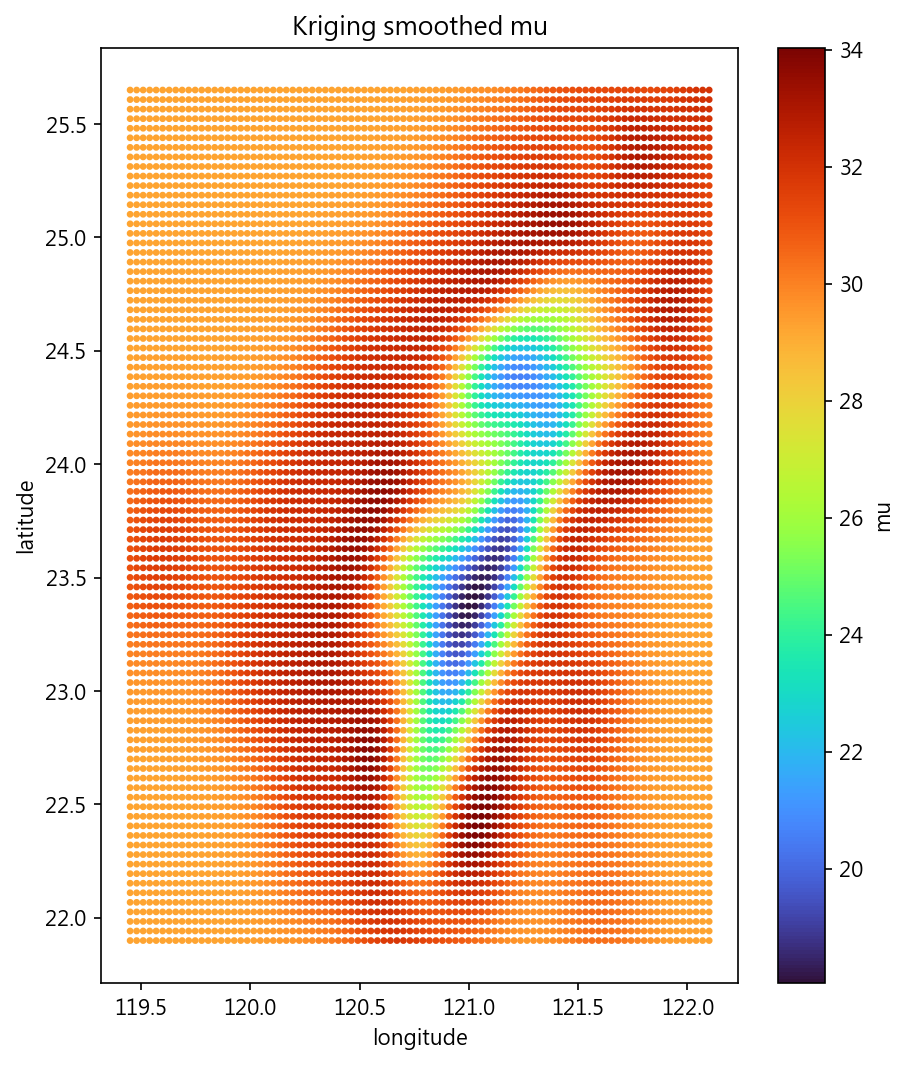

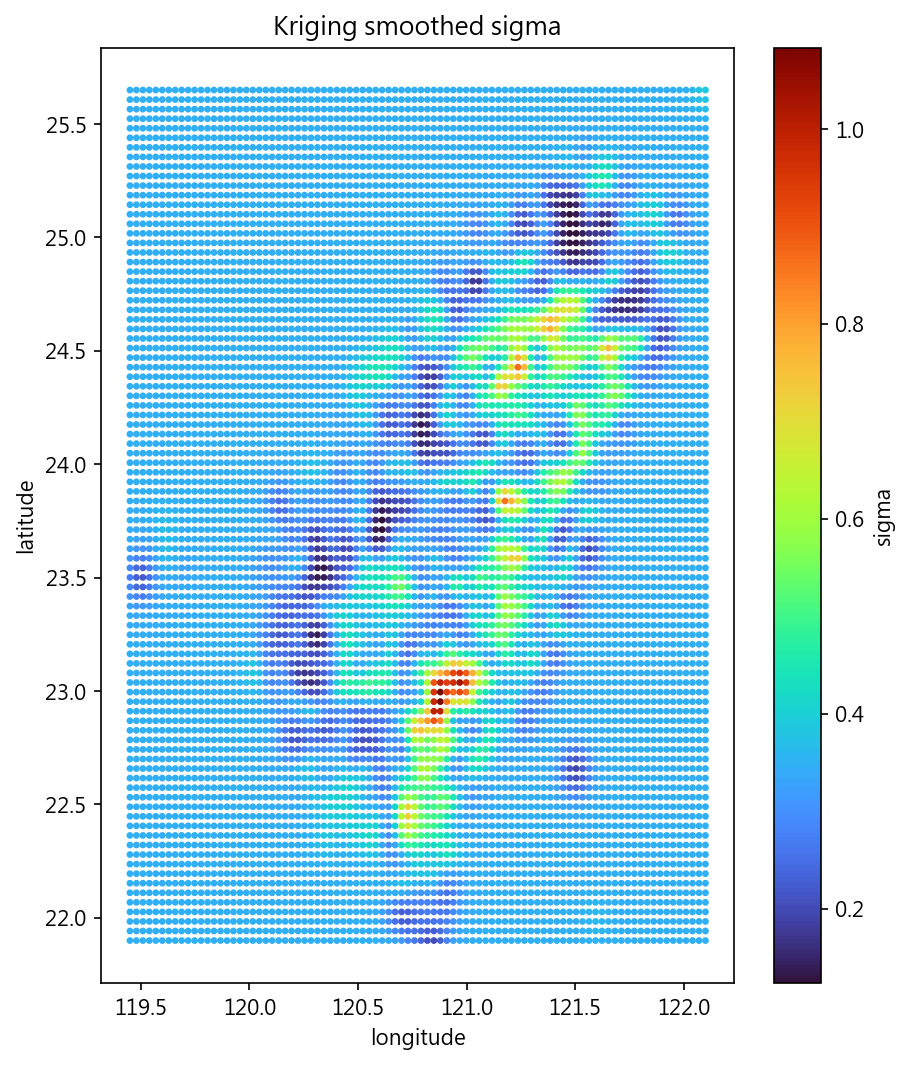

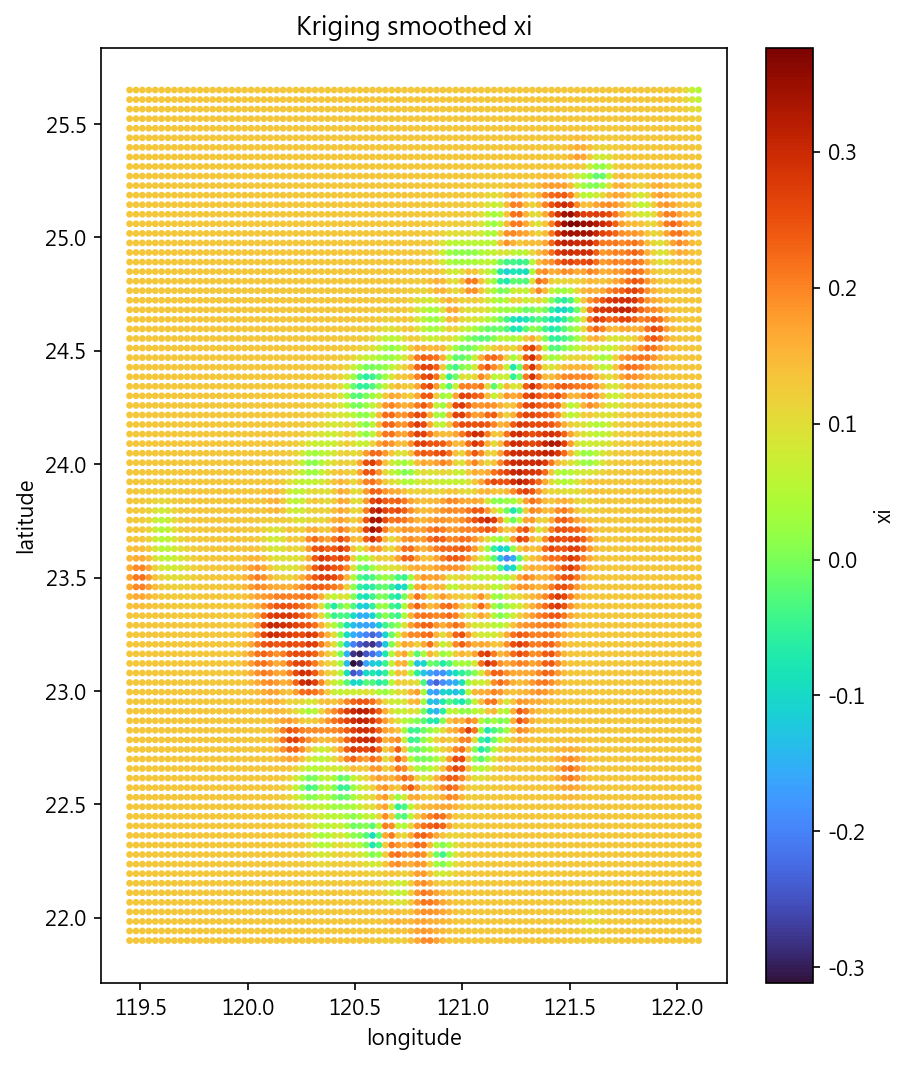

kriging grid shape: (8100, 9)


,lon,lat,mu,mu_std,log_sigma,log_sigma_std,xi,xi_std,sigma
0,119.450000,21.9,29.268263,3.275147,-1.064603,0.328774,0.129512,0.108587,0.344865
1,119.479775,21.9,29.268263,3.275147,-1.064603,0.328774,0.129512,0.108587,0.344865
2,119.509551,21.9,29.268264,3.275147,-1.064603,0.328774,0.129512,0.108587,0.344865
3,119.539326,21.9,29.268264,3.275147,-1.064603,0.328774,0.129512,0.108587,0.344865
4,119.569101,21.9,29.268266,3.275147,-1.064603,0.328774,0.129512,0.108587,0.344865


In [8]:

# =========================
# 空間平滑：沿用原專案 GP/Kriging 想法，但網格點很多時用抽樣避免過慢
# =========================
def fit_gp_and_predict(df, target_col, grid_raw, max_train=800):
    train_df = df[["lon", "lat", target_col]].dropna().copy()
    if len(train_df) > max_train:
        train_df = train_df.sample(max_train, random_state=123)

    X_raw = train_df[["lon", "lat"]].to_numpy()
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0)
    X = (X_raw - X_mean) / X_std
    X_grid = (grid_raw - X_mean) / X_std
    y = train_df[target_col].to_numpy()

    kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, normalize_y=True, random_state=123)
    gp.fit(X, y)
    pred, std = gp.predict(X_grid, return_std=True)
    return pred, std, str(gp.kernel_), len(train_df)

lon_grid = np.linspace(station_gev["lon"].min(), station_gev["lon"].max(), 90)
lat_grid = np.linspace(station_gev["lat"].min(), station_gev["lat"].max(), 90)
grid_raw = np.array([[lon, lat] for lat in lat_grid for lon in lon_grid])
grid_out = pd.DataFrame(grid_raw, columns=["lon", "lat"])

kernel_rows = []
for source_col, out_col in [("mu_hat", "mu"), ("log_sigma_hat", "log_sigma"), ("xi_hat", "xi")]:
    pred, std, kernel_text, n_train = fit_gp_and_predict(station_gev, source_col, grid_raw)
    grid_out[out_col] = pred
    grid_out[f"{out_col}_std"] = std
    kernel_rows.append({"target": out_col, "n_train_used": n_train, "kernel": kernel_text})

grid_out["sigma"] = np.exp(grid_out["log_sigma"])

for col, title, filename in [("mu", "Kriging smoothed mu", "kriging_mu.png"), ("sigma", "Kriging smoothed sigma", "kriging_sigma.png"), ("xi", "Kriging smoothed xi", "kriging_xi.png")]:
    fig, ax = plt.subplots(figsize=(6.2, 7.2), dpi=150)
    sc = ax.scatter(grid_out["lon"], grid_out["lat"], c=grid_out[col], s=5, cmap="turbo")
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    fig.colorbar(sc, ax=ax, label=col)
    fig.tight_layout()
    plt.show()

print("kriging grid shape:", grid_out.shape)
grid_out.head()

## 8. Main 內直接顯示

這一版 notebook 以課堂展示為主：圖形都直接顯示在 main 裡，不另外輸出圖片檔或 CSV。

In [9]:
# =========================
# 本次 main 內已直接顯示圖形
# =========================
print("本 notebook 已改成直接在 main 裡顯示圖形；這一版不再另外輸出 CSV 或圖片檔。")
print("目前保留在記憶體中的主要結果：")
print("- annual_max", annual_max.shape)
print("- station_gev", station_gev.shape)
print("- grid_out", grid_out.shape)

本 notebook 已改成直接在 main 裡顯示圖形；這一版不再另外輸出 CSV 或圖片檔。
目前保留在記憶體中的主要結果：
- annual_max (45, 1412)
- station_gev (1412, 8)
- grid_out (8100, 9)


## 9. 模擬網格資料驗證

這裡用新增的 0.5 度格點資料做 NN prediction，不使用 25 測站資料做估計。流程是：先在 0.5 度格點上指定真實 `mu`、`sigma`、`xi` surface，再分別模擬年度 45 筆 block maxima 與 monthly 540 筆 block maxima，最後用同一個 NN 對每個格點估計參數。

這一格只顯示真實 surface、年度 NN prediction surface、monthly NN prediction surface。RBF / Matérn kernel grid search 會放在下一格，避免流程混在一起。圖只在 main 中直接顯示，不另外輸出成圖片或 CSV，也不疊紅點。

C:\Users\User.DESKTOP-4RV84M1\AppData\Local\Temp\ipykernel_17568\1815806312.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sim_annual[row.station] = gev.rvs(
C:\Users\User.DESKTOP-4RV84M1\AppData\Local\Temp\ipykernel_17568\1815806312.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sim_monthly[row.station] = gev.rvs(


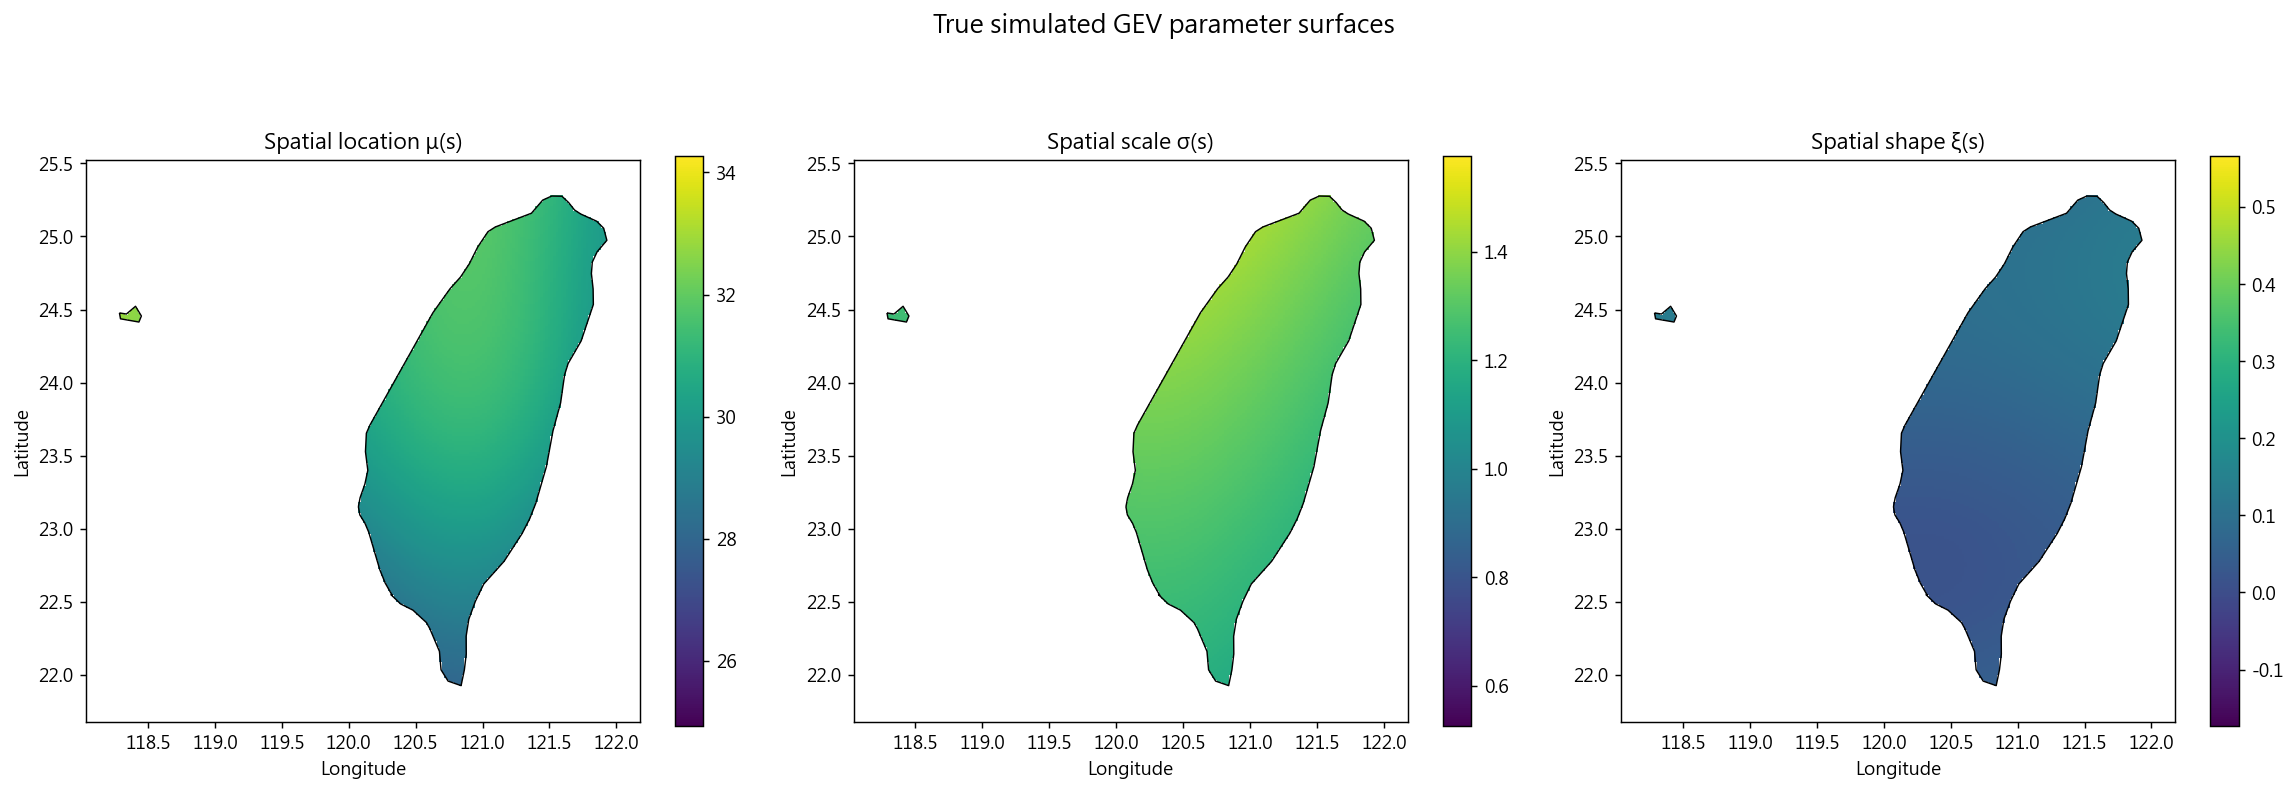

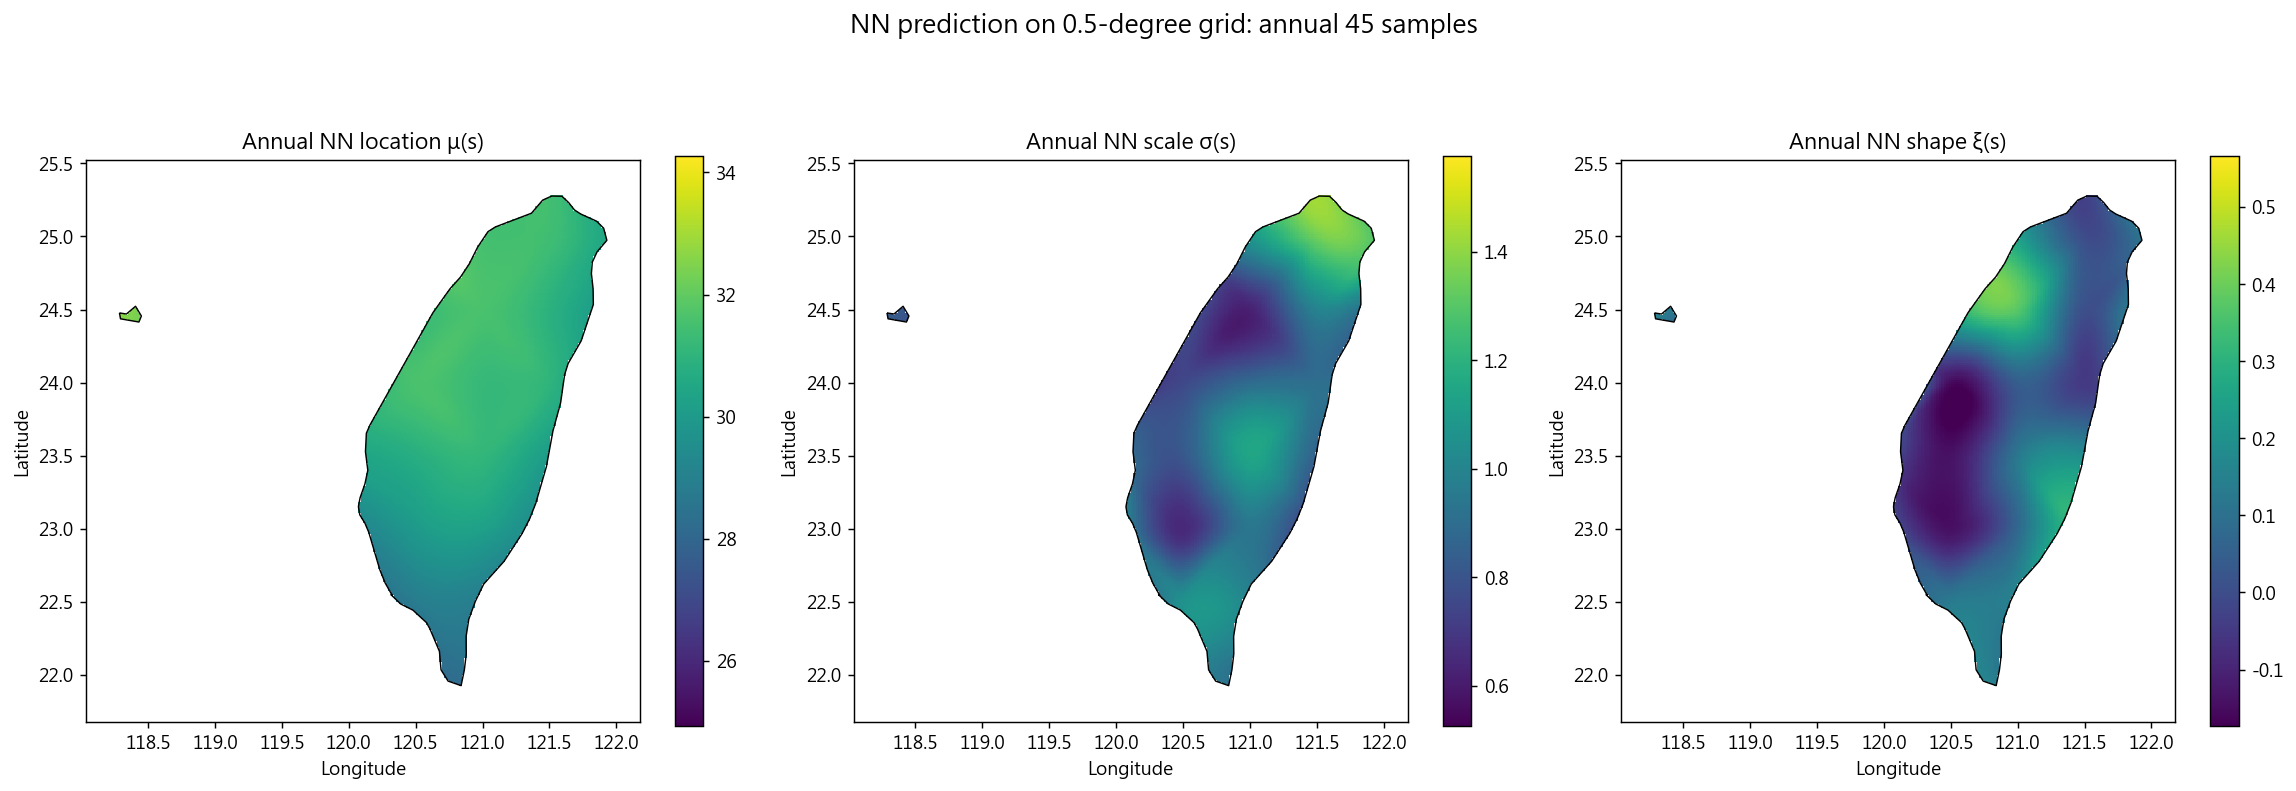

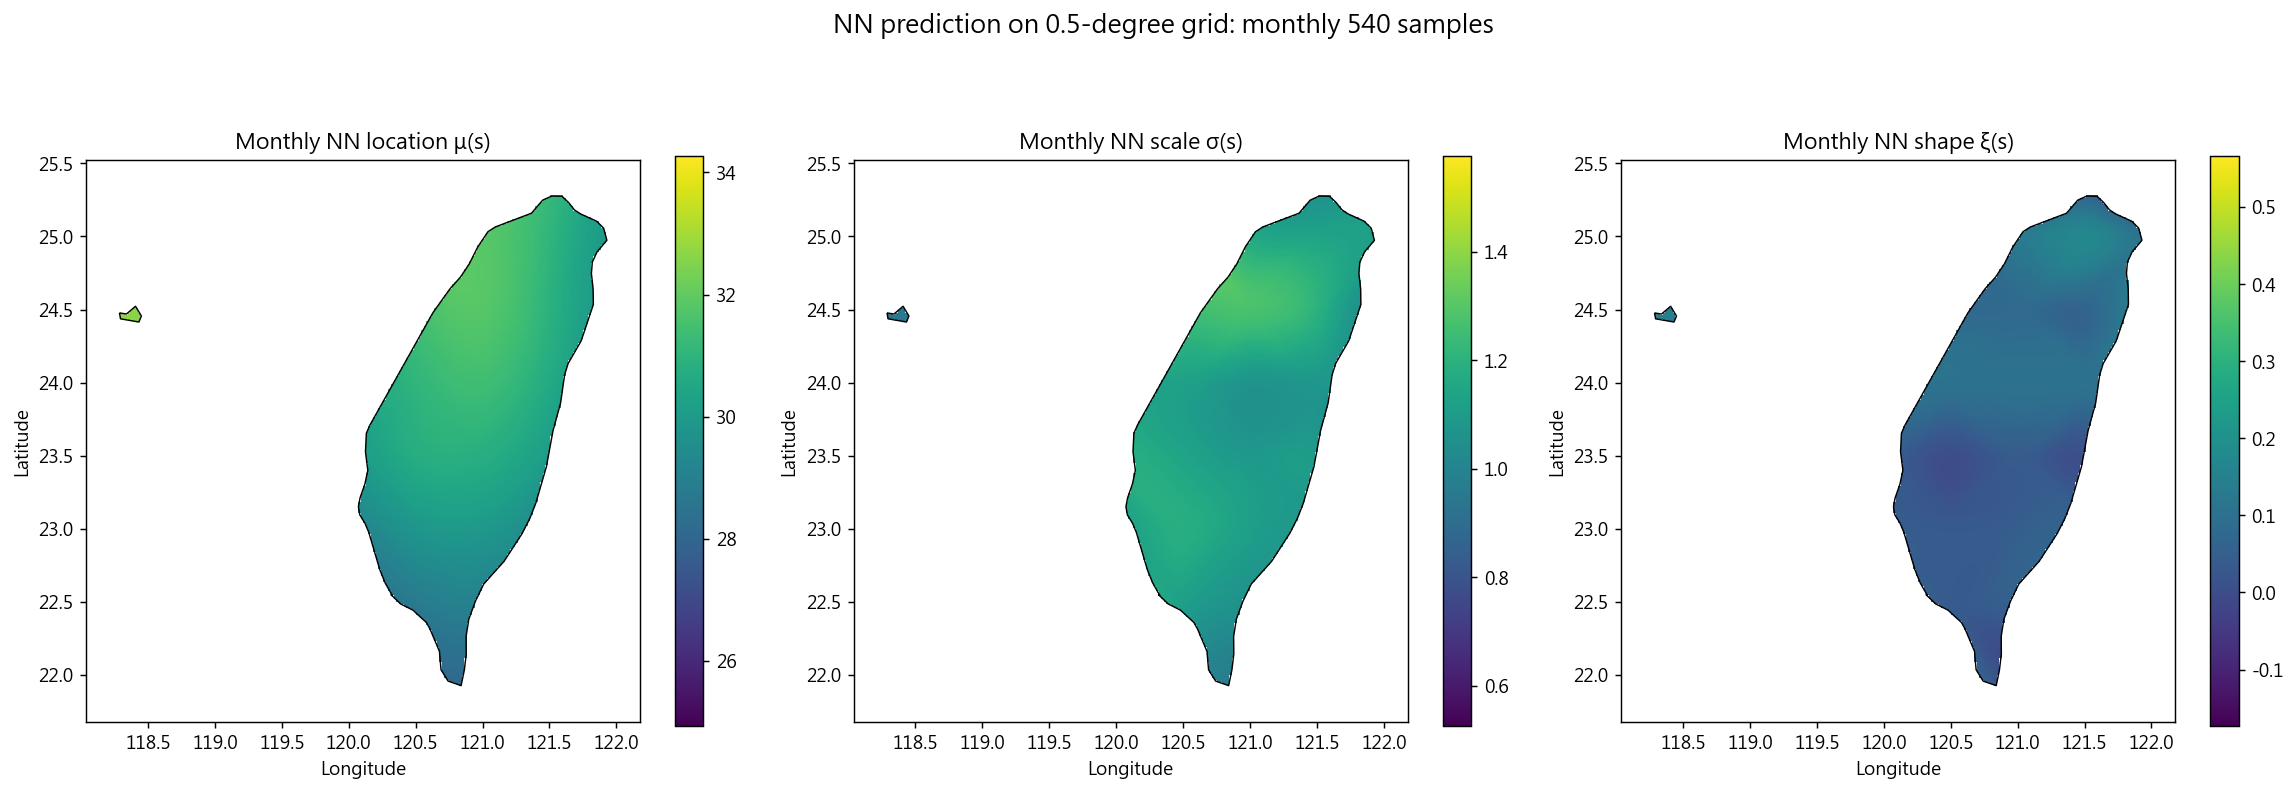

In [10]:
# =========================
# 模擬驗證：0.5 度網格真實 surface vs NN 預測 surface
# =========================
from scipy.stats import genextreme as gev
from scipy.interpolate import griddata
from shapely import contains_xy

# 這段只在 main 裡直接顯示圖，不輸出 CSV 或圖片檔。
SIM_SEED = 20260525
SIM_YEARS = 45
SIM_MONTHS = 12
SIM_GRID_STEP = 0.5
rng = np.random.default_rng(SIM_SEED)

# 讀臺灣邊界，讓模擬圖呈現方式接近原專案後面的 1x3 surface 圖。
world = gpd.read_file(SHAPEFILE_PATH)
taiwan = world[world["ADMIN"].str.contains("Taiwan", case=False, na=False)]
if taiwan.empty:
    taiwan = world[world["NAME"].str.contains("Taiwan", case=False, na=False)]
taiwan = taiwan.to_crs(epsg=4326)

lon_min, lat_min, lon_max, lat_max = taiwan.total_bounds
pad = 0.25
lon_min, lon_max = lon_min - pad, lon_max + pad
lat_min, lat_max = lat_min - pad, lat_max + pad

# 0.5 度格點：NN prediction 使用這批新增格點資料，不使用 25 測站資料做估計。
sim_lons = np.arange(np.floor(lon_min / SIM_GRID_STEP) * SIM_GRID_STEP, np.ceil(lon_max / SIM_GRID_STEP) * SIM_GRID_STEP + SIM_GRID_STEP / 2, SIM_GRID_STEP)
sim_lats = np.arange(np.floor(lat_min / SIM_GRID_STEP) * SIM_GRID_STEP, np.ceil(lat_max / SIM_GRID_STEP) * SIM_GRID_STEP + SIM_GRID_STEP / 2, SIM_GRID_STEP)
sim_grid = pd.DataFrame([(lon, lat) for lat in sim_lats for lon in sim_lons], columns=["lon", "lat"])
sim_grid["station"] = "SIM" + sim_grid["lon"].map(lambda x: f"{x:.1f}") + "_" + sim_grid["lat"].map(lambda x: f"{x:.1f}")

lon_s = (sim_grid["lon"] - sim_grid["lon"].mean()) / sim_grid["lon"].std()
lat_s = (sim_grid["lat"] - sim_grid["lat"].mean()) / sim_grid["lat"].std()

sim_grid["true_mu"] = 30.0 + 1.6 * lat_s - 0.7 * lon_s + 0.9 * np.sin(np.pi * lon_s) + 0.6 * np.cos(np.pi * lat_s / 1.5)
sim_grid["true_log_sigma"] = np.log(1.25) + 0.10 * lat_s + 0.08 * np.cos(np.pi * lon_s / 1.8)
sim_grid["true_sigma"] = np.exp(sim_grid["true_log_sigma"])
sim_grid["true_xi"] = 0.08 + 0.04 * np.sin(np.pi * lat_s / 1.4) - 0.025 * np.cos(np.pi * lon_s / 1.7)
sim_grid["true_xi"] = sim_grid["true_xi"].clip(-0.20, 0.30)

# 年度版本：45 年年最大值。
sim_annual = pd.DataFrame({"year": np.arange(1980, 1980 + SIM_YEARS)})
for row in sim_grid.itertuples(index=False):
    sim_annual[row.station] = gev.rvs(
        c=-row.true_xi,
        loc=row.true_mu,
        scale=row.true_sigma,
        size=SIM_YEARS,
        random_state=rng,
    )

# 新增版本：45 年 x 12 個月 monthly block maxima。
sim_monthly = pd.DataFrame({
    "year": np.repeat(np.arange(1980, 1980 + SIM_YEARS), SIM_MONTHS),
    "month": np.tile(np.arange(1, SIM_MONTHS + 1), SIM_YEARS),
})
for row in sim_grid.itertuples(index=False):
    sim_monthly[row.station] = gev.rvs(
        c=-row.true_xi,
        loc=row.true_mu,
        scale=row.true_sigma,
        size=SIM_YEARS * SIM_MONTHS,
        random_state=rng,
    )

def estimate_simulated_grid(block_df, scenario_name, id_cols):
    rows = []
    station_cols = [c for c in block_df.columns if c not in id_cols]
    for station in station_cols:
        y = block_df[station].dropna().to_numpy()
        mu, sigma, shape_c = estimate_one_station(model, y, device)
        rows.append({
            "scenario": scenario_name,
            "station": station,
            "n_obs": int(len(y)),
            "mu_hat": mu,
            "sigma_hat": sigma,
            "log_sigma_hat": float(np.log(sigma)),
            "shape_c_hat": shape_c,
            "xi_hat": -shape_c,
        })
    return pd.DataFrame(rows).merge(
        sim_grid[["station", "lon", "lat", "true_mu", "true_sigma", "true_log_sigma", "true_xi"]],
        on="station",
        how="left",
    )

sim_pred_annual = estimate_simulated_grid(sim_annual, "annual_45", id_cols=["year"])
sim_pred_monthly = estimate_simulated_grid(sim_monthly, "monthly_540", id_cols=["year", "month"])

# 將離散 0.5 度格點補成平滑網格，並只在臺灣 polygon 範圍內顯示。
plot_lons = np.linspace(lon_min, lon_max, 220)
plot_lats = np.linspace(lat_min, lat_max, 260)
plot_lon_grid, plot_lat_grid = np.meshgrid(plot_lons, plot_lats)
taiwan_geom = taiwan.geometry.union_all()
taiwan_mask = contains_xy(taiwan_geom, plot_lon_grid, plot_lat_grid)

def parameter_color_limits(frames, col_groups):
    limits = []
    for group in col_groups:
        values = []
        for df, col in zip(frames, group):
            values.append(df[col].to_numpy(dtype=float))
        values = np.concatenate(values)
        limits.append((float(np.nanmin(values)), float(np.nanmax(values))))
    return limits

simulation_color_limits = parameter_color_limits(
    frames=[sim_grid, sim_pred_annual, sim_pred_monthly],
    col_groups=[
        ["true_mu", "mu_hat", "mu_hat"],
        ["true_sigma", "sigma_hat", "sigma_hat"],
        ["true_xi", "xi_hat", "xi_hat"],
    ],
)

def plot_parameter_surfaces_1x3(df, cols, titles, main_title, color_limits=simulation_color_limits):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130)
    for ax, col, title, (vmin, vmax) in zip(axes, cols, titles, color_limits):
        z = griddata(
            df[["lon", "lat"]].to_numpy(),
            df[col].to_numpy(),
            (plot_lon_grid, plot_lat_grid),
            method="cubic",
        )
        z = np.where(taiwan_mask, z, np.nan)
        mesh = ax.pcolormesh(plot_lon_grid, plot_lat_grid, z, shading="auto", cmap="viridis", vmin=vmin, vmax=vmax)
        taiwan.boundary.plot(ax=ax, color="black", linewidth=0.8)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        fig.colorbar(mesh, ax=ax, shrink=0.82)
    fig.suptitle(main_title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

plot_parameter_surfaces_1x3(
    sim_grid,
    ["true_mu", "true_sigma", "true_xi"],
    ["Spatial location μ(s)", "Spatial scale σ(s)", "Spatial shape ξ(s)"],
    "True simulated GEV parameter surfaces",
)

plot_parameter_surfaces_1x3(
    sim_pred_annual,
    ["mu_hat", "sigma_hat", "xi_hat"],
    ["Annual NN location μ(s)", "Annual NN scale σ(s)", "Annual NN shape ξ(s)"],
    "NN prediction on 0.5-degree grid: annual 45 samples",
)

plot_parameter_surfaces_1x3(
    sim_pred_monthly,
    ["mu_hat", "sigma_hat", "xi_hat"],
    ["Monthly NN location μ(s)", "Monthly NN scale σ(s)", "Monthly NN shape ξ(s)"],
    "NN prediction on 0.5-degree grid: monthly 540 samples",
)


## 10. RBF / Matérn Grid Search

這一格改成完整版本：每個 RBF / Matérn 候選 kernel 都會先以指定的 initial length scale 建立模型，接著讓 `GaussianProcessRegressor` 做 marginal likelihood hyperparameter optimization，並使用 `n_restarts_optimizer = 10`。

Matérn 的搜尋包含 `length_scale × nu`；RBF 搜尋 `length_scale`。每個候選 fit 完後，用已知真實 surface 計算 RMSE 與 standardized RMSE。最後對 `mu`、`sigma`、`xi` 各自挑最佳 kernel，因為三個參數的 spatial smoothness 不一定相同。這格會比前面快篩版慢很多。

In [11]:
# =========================
# RBF / Matérn kernel grid search：完整 GP hyperparameter optimization
# =========================
from sklearn.gaussian_process.kernels import Matern
from sklearn.base import clone
import os
from joblib import Parallel, delayed

# 這一格是完整版，會比前面快篩版慢很多。
# 邏輯：對每個 kernel family / initial length_scale / Matérn nu 候選值，
# 都讓 GaussianProcessRegressor 再做 marginal likelihood hyperparameter optimization，
# 然後用已知真實 surface 算 RMSE，選出最佳 kernel。
GP_N_RESTARTS = 10
GP_N_JOBS = max(1, (os.cpu_count() or 2) - 1)
print(f"Parallel GP grid search jobs: {GP_N_JOBS}")
GP_LENGTH_SCALES = np.unique(np.append(np.round(np.arange(0.05, 5.0, 0.1), 2), 5.0))
GP_MATERN_NUS = (0.5, 1.5, 2.5)

def standardize_xy(df):
    xy = df[["lon", "lat"]].to_numpy(dtype=float)
    mean = xy.mean(axis=0)
    std = xy.std(axis=0)
    std[std == 0] = 1.0
    return (xy - mean) / std, mean, std

def optimized_gp_kernel(kernel_name, initial_length_scale, nu=None):
    if kernel_name == "RBF":
        spatial_kernel = RBF(
            length_scale=initial_length_scale,
            length_scale_bounds=(1e-2, 10.0),
        )
    elif kernel_name == "Matern":
        spatial_kernel = Matern(
            length_scale=initial_length_scale,
            length_scale_bounds=(1e-2, 10.0),
            nu=nu,
        )
    else:
        raise ValueError(kernel_name)

    return (
        C(1.0, constant_value_bounds=(1e-2, 1e2))
        * spatial_kernel
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
    )

def fit_optimized_gp(train_df, source_col, kernel_name, initial_length_scale, nu=None):
    x_train, coord_mean, coord_std = standardize_xy(train_df)
    y = train_df[source_col].to_numpy(dtype=float)
    gp = GaussianProcessRegressor(
        kernel=optimized_gp_kernel(kernel_name, initial_length_scale, nu=nu),
        n_restarts_optimizer=GP_N_RESTARTS,
        normalize_y=True,
        random_state=SIM_SEED,
    )
    gp.fit(x_train, y)
    return gp, coord_mean, coord_std

def predict_with_fitted_gp(gp, coord_mean, coord_std, pred_df):
    x_pred = (pred_df[["lon", "lat"]].to_numpy(dtype=float) - coord_mean) / coord_std
    return gp.predict(x_pred)

def evaluate_gp_candidate(train_df, true_df, scenario_name, param, true_col, source_col, scale, kernel_name, initial_length_scale, nu):
    gp, coord_mean, coord_std = fit_optimized_gp(
        train_df=train_df,
        source_col=source_col,
        kernel_name=kernel_name,
        initial_length_scale=float(initial_length_scale),
        nu=None if pd.isna(nu) else float(nu),
    )
    pred = predict_with_fitted_gp(gp, coord_mean, coord_std, true_df)
    true_values = true_df[true_col].to_numpy(dtype=float)
    err = pred - true_values
    return {
        "scenario": scenario_name,
        "param": param,
        "kernel": kernel_name,
        "initial_length_scale": float(initial_length_scale),
        "nu": nu,
        "rmse": float(np.sqrt(np.mean(err**2))),
        "standardized_rmse": float(np.sqrt(np.mean((err / scale) ** 2))),
        "optimized_kernel": str(gp.kernel_),
        "optimized_kernel_object": clone(gp.kernel_),
        "log_marginal_likelihood": float(gp.log_marginal_likelihood(gp.kernel_.theta)),
    }

def add_overall_rmse_rows(search):
    rows = []
    group_cols = ["scenario", "kernel", "initial_length_scale", "nu"]
    metric_rows = search[search["param"].isin(["mu", "sigma", "xi"])].copy()

    for keys, group in metric_rows.groupby(group_cols, dropna=False):
        scenario, kernel, initial_length_scale, nu = keys
        if set(group["param"]) != {"mu", "sigma", "xi"}:
            continue

        overall_rmse = float(np.sqrt(np.mean(group["rmse"].to_numpy(dtype=float) ** 2)))
        overall_standardized_rmse = float(np.sqrt(np.mean(group["standardized_rmse"].to_numpy(dtype=float) ** 2)))
        mean_lml = float(group["log_marginal_likelihood"].mean())

        rows.append({
            "scenario": scenario,
            "param": "overall",
            "kernel": kernel,
            "initial_length_scale": float(initial_length_scale),
            "nu": nu,
            "rmse": overall_rmse,
            "standardized_rmse": np.nan,
            "optimized_kernel": "see parameter-specific rows",
            "optimized_kernel_object": None,
            "log_marginal_likelihood": mean_lml,
        })
        rows.append({
            "scenario": scenario,
            "param": "overall_standardized",
            "kernel": kernel,
            "initial_length_scale": float(initial_length_scale),
            "nu": nu,
            "rmse": np.nan,
            "standardized_rmse": overall_standardized_rmse,
            "optimized_kernel": "see parameter-specific rows",
            "optimized_kernel_object": None,
            "log_marginal_likelihood": mean_lml,
        })

    if rows:
        search = pd.concat([search, pd.DataFrame(rows)], ignore_index=True)
    return search

def full_gp_grid_search(train_df, true_df, scenario_name):
    candidates = [("RBF", ls, np.nan) for ls in GP_LENGTH_SCALES]
    candidates += [("Matern", ls, nu) for nu in GP_MATERN_NUS for ls in GP_LENGTH_SCALES]
    targets = [
        ("mu", "true_mu", "mu_hat"),
        ("sigma", "true_sigma", "sigma_hat"),
        ("xi", "true_xi", "xi_hat"),
    ]

    rows = []

    for param, true_col, source_col in targets:
        true_values = true_df[true_col].to_numpy(dtype=float)
        scale = true_values.std()
        if scale == 0:
            scale = 1.0

        param_rows = Parallel(n_jobs=GP_N_JOBS, prefer="processes")(
            delayed(evaluate_gp_candidate)(
                train_df,
                true_df,
                scenario_name,
                param,
                true_col,
                source_col,
                scale,
                kernel_name,
                initial_length_scale,
                nu,
            )
            for kernel_name, initial_length_scale, nu in candidates
        )
        rows.extend(param_rows)

    search = add_overall_rmse_rows(pd.DataFrame(rows))

    # 每個參數各自選最佳 kernel；這比用 overall 單一 kernel 更貼近實際建模，
    # 因為 mu / sigma / xi 的 spatial smoothness 可以不同。
    param_search = search[search["param"].isin(["mu", "sigma", "xi"])]
    best_rows = param_search.loc[param_search.groupby("param")["standardized_rmse"].idxmin()].copy()
    out = true_df[["station", "lon", "lat", "true_mu", "true_sigma", "true_xi"]].copy()

    for _, best in best_rows.iterrows():
        param = best["param"]
        source_col = f"{param}_hat"
        gp, coord_mean, coord_std = fit_optimized_gp(
            train_df=train_df,
            source_col=source_col,
            kernel_name=best["kernel"],
            initial_length_scale=float(best["initial_length_scale"]),
            nu=None if pd.isna(best["nu"]) else float(best["nu"]),
        )
        out[f"{param}_kriged"] = predict_with_fitted_gp(gp, coord_mean, coord_std, true_df)
        out[f"{param}_best_kernel"] = best["kernel"]
        out[f"{param}_best_initial_length_scale"] = float(best["initial_length_scale"])
        out[f"{param}_best_nu"] = best["nu"]
        out[f"{param}_optimized_kernel"] = str(gp.kernel_)

    out["scenario"] = scenario_name
    return search, best_rows, out

search_annual, best_annual, sim_kriged_annual = full_gp_grid_search(sim_pred_annual, sim_grid, "annual_45")
search_monthly, best_monthly, sim_kriged_monthly = full_gp_grid_search(sim_pred_monthly, sim_grid, "monthly_540")
search_all = pd.concat([search_annual, search_monthly], ignore_index=True)
best_summary = pd.concat([best_annual, best_monthly], ignore_index=True)

def select_best_gridsearch_rows(search):
    rows = []
    for scenario, scenario_df in search.groupby("scenario"):
        metric_df = scenario_df[scenario_df["param"].isin(["mu", "sigma", "xi"])]
        rows.append(metric_df.loc[metric_df.groupby("param")["standardized_rmse"].idxmin()])

        overall_df = scenario_df[scenario_df["param"] == "overall"]
        if not overall_df.empty:
            rows.append(overall_df.loc[[overall_df["rmse"].idxmin()]])

        overall_std_df = scenario_df[scenario_df["param"] == "overall_standardized"]
        if not overall_std_df.empty:
            rows.append(overall_std_df.loc[[overall_std_df["standardized_rmse"].idxmin()]])

    return pd.concat(rows, ignore_index=True)

best_gridsearch_summary = select_best_gridsearch_rows(search_all)
display(best_gridsearch_summary[[
    "scenario", "param", "kernel", "initial_length_scale", "nu",
    "rmse", "standardized_rmse", "optimized_kernel", "log_marginal_likelihood"
]])

def summarize_error(df, scenario_name, pred_cols):
    rows = []
    for param, true_col, pred_col in pred_cols:
        err = df[pred_col] - df[true_col]
        rows.append({
            "scenario": scenario_name,
            "param": param,
            "rmse": float(np.sqrt(np.mean(err**2))),
            "mae": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)),
            "correlation": float(df[[true_col, pred_col]].corr().iloc[0, 1]),
        })
    return pd.DataFrame(rows)

sim_error = pd.concat([
    summarize_error(sim_pred_annual, "annual_45_raw_nn_grid", [("mu", "true_mu", "mu_hat"), ("sigma", "true_sigma", "sigma_hat"), ("xi", "true_xi", "xi_hat")]),
    summarize_error(sim_pred_monthly, "monthly_540_raw_nn_grid", [("mu", "true_mu", "mu_hat"), ("sigma", "true_sigma", "sigma_hat"), ("xi", "true_xi", "xi_hat")]),
    summarize_error(sim_kriged_annual, "annual_45_full_gp_gridsearch", [("mu", "true_mu", "mu_kriged"), ("sigma", "true_sigma", "sigma_kriged"), ("xi", "true_xi", "xi_kriged")]),
    summarize_error(sim_kriged_monthly, "monthly_540_full_gp_gridsearch", [("mu", "true_mu", "mu_kriged"), ("sigma", "true_sigma", "sigma_kriged"), ("xi", "true_xi", "xi_kriged")]),
], ignore_index=True)
display(sim_error)

# 更新共用色階：同一個參數在 true / raw NN / full GP grid-search 圖之間使用同一個 vmin/vmax。
simulation_color_limits = parameter_color_limits(
    frames=[sim_grid, sim_pred_annual, sim_pred_monthly, sim_kriged_annual, sim_kriged_monthly],
    col_groups=[
        ["true_mu", "mu_hat", "mu_hat", "mu_kriged", "mu_kriged"],
        ["true_sigma", "sigma_hat", "sigma_hat", "sigma_kriged", "sigma_kriged"],
        ["true_xi", "xi_hat", "xi_hat", "xi_kriged", "xi_kriged"],
    ],
)


Parallel GP grid search jobs: 11


KeyboardInterrupt: 

In [ ]:
kernel_compare = []

for scenario in ["annual_45", "monthly_540"]:
    for param in ["mu", "sigma", "xi", "overall", "overall_standardized"]:
        sub = search_all[
            (search_all["scenario"] == scenario)
            & (search_all["param"] == param)
        ].copy()

        if param == "overall":
            best_by_kernel = sub.loc[sub.groupby("kernel")["rmse"].idxmin()]
            metric = "rmse"
        else:
            best_by_kernel = sub.loc[sub.groupby("kernel")["standardized_rmse"].idxmin()]
            metric = "standardized_rmse"

        rbf = best_by_kernel.loc[best_by_kernel["kernel"] == "RBF", metric].iloc[0]
        matern = best_by_kernel.loc[best_by_kernel["kernel"] == "Matern", metric].iloc[0]

        better = "RBF" if rbf < matern else "Matérn"

        kernel_compare.append({
            "scenario": scenario,
            "param": param,
            "matern": matern,
            "rbf": rbf,
            "better": better,
            "metric": metric,
        })

kernel_compare = pd.DataFrame(kernel_compare)
display(kernel_compare)

,scenario,param,matern,rbf,better,metric
0,annual_45,mu,0.072235,0.068455,RBF,standardized_rmse
1,annual_45,sigma,2.678828,2.687382,Matérn,standardized_rmse
2,annual_45,xi,4.256002,3.861605,RBF,standardized_rmse
3,annual_45,overall,0.250196,0.246821,RBF,rmse
4,annual_45,overall_standardized,2.904138,2.716536,RBF,standardized_rmse
5,monthly_540,mu,0.025950,0.019274,RBF,standardized_rmse
6,monthly_540,sigma,1.442049,1.425994,RBF,standardized_rmse
7,monthly_540,xi,1.030043,1.051729,Matérn,standardized_rmse
8,monthly_540,overall,0.124881,0.121876,RBF,rmse
9,monthly_540,overall_standardized,1.024811,1.023062,RBF,standardized_rmse


: 

In [ ]:
plot_parameter_surfaces_1x3(
    sim_kriged_annual,
    ["mu_kriged", "sigma_kriged", "xi_kriged"],
    ["Annual kriged location μ(s)", "Annual kriged scale σ(s)", "Annual kriged shape ξ(s)"],
    "RBF/Matérn GP optimization + grid search: annual 45 samples",
)

plot_parameter_surfaces_1x3(
    sim_kriged_monthly,
    ["mu_kriged", "sigma_kriged", "xi_kriged"],
    ["Monthly kriged location μ(s)", "Monthly kriged scale σ(s)", "Monthly kriged shape ξ(s)"],
    "RBF/Matérn GP optimization + grid search: monthly 540 samples",
)

## 11. 真實資料套用 Optimal Covariance

這一格回到真實最高溫資料。第 10 節已經在模擬資料中找出 optimal RBF / Matérn covariance 超參數；這裡直接套用那些 optimal kernel 參數，不再重新做 marginal likelihood optimization。

也就是：第 10 節負責找最佳 covariance，第 11 節只把固定好的 covariance 帶到真實資料上做 GP prediction。真實資料沒有 ground truth GEV 參數，因此這裡不計算 RMSE，只呈現套用 optimal covariance 後的 `mu/sigma/xi` 1×3 圖。

In [ ]:
# =========================
# 真實資料：套用第 10 節 optimal RBF / Matérn covariance 設定
# =========================
# 使用 monthly_540 的模擬驗證結果當作優先設定，因為它對 sigma / xi 較穩定。
REAL_OPTIMAL_SCENARIO = "monthly_540"

# 真實資料已經在前面得到 station_gev，欄位包含 lon / lat / mu_hat / sigma_hat / xi_hat。
real_train = station_gev[["station", "lon", "lat", "mu_hat", "sigma_hat", "xi_hat"]].dropna().copy()

# 畫圖用的臺灣範圍與 mask 若前面沒有執行第 9 節，這裡補上。
if "taiwan" not in globals():
    world = gpd.read_file(SHAPEFILE_PATH)
    taiwan = world[world["ADMIN"].str.contains("Taiwan", case=False, na=False)]
    if taiwan.empty:
        taiwan = world[world["NAME"].str.contains("Taiwan", case=False, na=False)]
    taiwan = taiwan.to_crs(epsg=4326)

if "plot_lon_grid" not in globals():
    lon_min, lat_min, lon_max, lat_max = taiwan.total_bounds
    pad = 0.25
    lon_min, lon_max = lon_min - pad, lon_max + pad
    lat_min, lat_max = lat_min - pad, lat_max + pad
    plot_lons = np.linspace(lon_min, lon_max, 220)
    plot_lats = np.linspace(lat_min, lat_max, 260)
    plot_lon_grid, plot_lat_grid = np.meshgrid(plot_lons, plot_lats)
    taiwan_geom = taiwan.geometry.union_all()
    taiwan_mask = contains_xy(taiwan_geom, plot_lon_grid, plot_lat_grid)

real_grid = pd.DataFrame({
    "lon": plot_lon_grid.ravel(),
    "lat": plot_lat_grid.ravel(),
})
real_grid = real_grid[np.ravel(taiwan_mask)].reset_index(drop=True)
real_grid["station"] = "REAL_GRID"

# 從第 10 節的完整 grid search 結果中，分別取 RBF / Matérn 在每個參數上的最佳設定。
def select_best_covariance_by_kernel(search_df, scenario, kernel_name):
    subset = search_df[
        (search_df["scenario"] == scenario)
        & (search_df["kernel"] == kernel_name)
        & (search_df["param"].isin(["mu", "sigma", "xi"]))
    ].copy()
    if subset.empty:
        raise ValueError(f"No grid-search result for scenario={scenario}, kernel={kernel_name}")
    return subset.loc[subset.groupby("param")["standardized_rmse"].idxmin()].copy()

best_real_rbf = select_best_covariance_by_kernel(search_all, REAL_OPTIMAL_SCENARIO, "RBF")
best_real_matern = select_best_covariance_by_kernel(search_all, REAL_OPTIMAL_SCENARIO, "Matern")

display(pd.concat([best_real_rbf, best_real_matern], ignore_index=True)[[
    "scenario", "param", "kernel", "initial_length_scale", "nu",
    "standardized_rmse", "optimized_kernel"
]])

# 套用 optimal covariance 到真實資料。這裡用最佳設定作為 initial kernel，並重新對真實資料做 GP hyperparameter optimization。
def apply_optimal_covariance_to_real(best_rows, kernel_label):
    out = real_grid[["station", "lon", "lat"]].copy()
    for _, best in best_rows.iterrows():
        param = best["param"]
        source_col = f"{param}_hat"
        gp, coord_mean, coord_std = fit_optimized_gp(
            train_df=real_train,
            source_col=source_col,
            kernel_name=best["kernel"],
            initial_length_scale=float(best["initial_length_scale"]),
            nu=None if pd.isna(best["nu"]) else float(best["nu"]),
        )
        out[param] = predict_with_fitted_gp(gp, coord_mean, coord_std, real_grid)
        out[f"{param}_optimized_kernel"] = str(gp.kernel_)
    out["covariance"] = kernel_label
    return out

real_rbf_surface = apply_optimal_covariance_to_real(best_real_rbf, "RBF")
real_matern_surface = apply_optimal_covariance_to_real(best_real_matern, "Matern")

# 真實資料 RBF / Matérn 共用同一套色階，方便比較兩種 covariance。
real_color_limits = parameter_color_limits(
    frames=[real_rbf_surface, real_matern_surface],
    col_groups=[
        ["mu", "mu"],
        ["sigma", "sigma"],
        ["xi", "xi"],
    ],
)

plot_parameter_surfaces_1x3(
    real_rbf_surface,
    ["mu", "sigma", "xi"],
    ["Real RBF location μ(s)", "Real RBF scale σ(s)", "Real RBF shape ξ(s)"],
    "Real high-temperature data with optimal RBF covariance",
    color_limits=real_color_limits,
)

plot_parameter_surfaces_1x3(
    real_matern_surface,
    ["mu", "sigma", "xi"],
    ["Real Matérn location μ(s)", "Real Matérn scale σ(s)", "Real Matérn shape ξ(s)"],
    "Real high-temperature data with optimal Matérn covariance",
    color_limits=real_color_limits,
)
